# Urban Crash Analytics: A Spatial Analysis of Road Collision Risk in New York City

**Student:** Saif Ullah (BSCS23065)  
**Course:** CS592-Spatial Data Science  
**Instructor:** Dr. Adnan Siddique  
**Institution:** Information Technology University, Lahore  
**Session:** Spring 2026  

---

## Abstract

Cities typically respond to dangerous roads only after repeated accidents have occurred. 
This project asks: can we predict which road segments are high risk *before* accidents happen, 
using spatial features and road infrastructure attributes?

We analyze 500,000 crash records from NYC (2021–2026), spatially join them to 122,272 road 
segments, compute a Collision Severity Index per segment, and apply spatial analysis techniques 
including choropleth mapping, Moran's I, LISA, Kernel Density Estimation, and spatial regression. 
We then train a Random Forest and XGBoost classifier using road infrastructure features to predict 
collision risk class (Low / Moderate / High), achieving F1 of 0.848 and AUC of 0.971.

## 1. Environment Setup

All required libraries are imported here. The project uses the following key libraries:
- **GeoPandas** - spatial data handling and spatial joins
- **OSMnx / NetworkX** - road network analysis
- **esda / libpysal** - spatial autocorrelation (Moran's I, LISA)
- **Scikit-Learn / XGBoost** - machine learning models
- **Folium** - interactive map visualization
- **imbalanced-learn** - SMOTE for class balancing

In [ ]:
# ── Core libraries 
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Visualization 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium

# ── Spatial analysis 
import libpysal
from esda.moran import Moran, Moran_Local
from scipy.stats import gaussian_kde
from shapely.geometry import Point

# ── Machine learning 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ── Paths - set once here, used throughout 
BASE     = Path("..") 
RAW      = BASE / "data" / "raw"
PROC     = BASE / "data" / "processed"
EXT      = BASE / "data" / "external"
FIGS     = BASE / "outputs" / "figures"
MAPS     = BASE / "outputs" / "maps"
FIGS.mkdir(parents=True, exist_ok=True)
MAPS.mkdir(parents=True, exist_ok=True)

print("All libraries loaded successfully.")
print(f"Working directory: {BASE.resolve()}")

All libraries loaded successfully.
Working directory: D:\SDS\Project\urban-crash-analytics


## 2. Data Collection

We use two primary datasets, both freely available:

### 2.1 NYC Motor Vehicle Collisions
- **Source:** NYC Open Data (Socrata API)
- **Records:** 500,000 crash records (2021–2026)
- **Key fields:** GPS coordinates, crash date/time, injuries, fatalities
- **Download method:** Paginated API requests (50,000 rows per chunk)

### 2.2 NYC Street Centerline
- **Source:** NYC Department of City Planning (GeoJSON API)
- **Records:** 122,272 road segments covering all five boroughs
- **Key fields:** Street name, speed limit, lane count, road type, traffic direction
- **Why this dataset:** Official NYC road network maintained by the city,
  more reliable than raw OpenStreetMap for administrative analysis

In [2]:
# load pre-downloaded datasets
# crashes were downloaded via Socrata API (see data_collection.ipynb)
# roads were downloaded via NYC Open Data GeoJSON API (see osm_network.ipynb)

crashes_raw = pd.read_csv(RAW / "crashes_raw.csv", low_memory=False)
roads       = gpd.read_file(EXT / "nyc_roads.gpkg")

print(f"Raw crash records: {len(crashes_raw):,}")
print(f"Road segments:     {len(roads):,}")
print(f"\nCrash columns: {list(crashes_raw.columns)}")
print(f"\nRoad CRS: {roads.crs}")

Raw crash records: 500,000
Road segments:     122,272

Crash columns: ['crash_date', 'crash_time', 'borough', 'zip_code', 'latitude', 'longitude', 'location', 'on_street_name', 'off_street_name', 'cross_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3', 'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5', 'collision_id', 'vehicle_type_code1', 'vehicle_type_code2', 'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5']

Road CRS: EPSG:4326


## 3. Data Preprocessing

### 3.1 Crash Data Cleaning
The following preprocessing steps were applied:

1. **DateTime parsing** - crash_date converted from ISO string to datetime
2. **GPS filtering** - rows with missing or zero coordinates dropped (7.7% of data)
3. **Column removal** - redundant and high-null columns dropped
4. **Null imputation** - one null in injuries column filled with 0

### 3.2 Collision Severity Index (CSI)
A custom severity metric was computed per crash:

$$CSI = 1 + (2 \times injuries) + (5 \times fatalities)$$

**Rationale:** Raw crash count treats all crashes equally. A fatal crash is 
catastrophically worse than a fender-bender. The 1/2/5 weights reflect this 
severity hierarchy and are consistent with traffic safety literature.

In [3]:
# ── Parse dates 
crashes_raw['crash_date'] = pd.to_datetime(crashes_raw['crash_date'])
crashes_raw['crash_datetime'] = pd.to_datetime(
    crashes_raw['crash_date'].dt.strftime('%Y-%m-%d') + ' ' + crashes_raw['crash_time'],
    errors='coerce'
)

# ── Drop rows without GPS 
before = len(crashes_raw)
crashes = crashes_raw[
    crashes_raw['latitude'].notnull() & crashes_raw['longitude'].notnull() &
    (crashes_raw['latitude'] != 0) & (crashes_raw['longitude'] != 0)
].copy()
print(f"Dropped {before - len(crashes):,} rows without GPS ({(before-len(crashes))/before*100:.1f}%)")
print(f"Remaining: {len(crashes):,}")

# ── Drop redundant columns 
drop_cols = ['location', 'vehicle_type_code_3', 'vehicle_type_code_4',
             'vehicle_type_code_5', 'contributing_factor_vehicle_3',
             'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5',
             'off_street_name']
crashes = crashes.drop(columns=[c for c in drop_cols if c in crashes.columns])

# ── Fix nulls 
crashes['number_of_persons_injured'] = crashes['number_of_persons_injured'].fillna(0).astype(int)
crashes['borough'] = crashes['borough'].str.strip().str.title()

# ── Collision Severity Index 
crashes['csi'] = 1 + 2 * crashes['number_of_persons_injured'] + 5 * crashes['number_of_persons_killed']

print(f"\nCSI distribution:")
print(crashes['csi'].describe().round(2))
print(f"\nCrashes with injuries/fatalities: {(crashes['csi'] > 1).sum():,}")

crashes.to_csv(PROC / "crashes_cleaned.csv", index=False)
print("\nSaved crashes_cleaned.csv")

Dropped 38,575 rows without GPS (7.7%)
Remaining: 461,425

CSI distribution:
count    461425.00
mean          2.08
std           1.68
min           1.00
25%           1.00
50%           1.00
75%           3.00
max          69.00
Name: csi, dtype: float64

Crashes with injuries/fatalities: 186,207

Saved crashes_cleaned.csv


## 4. Spatial Join - Connecting Crashes to Road Segments

### 4.1 Why Spatial Join?
Each crash record contains GPS coordinates but no road identifier. 
To analyze risk per road segment, we must snap each crash point to its 
nearest road segment. This is the core spatial operation of the project.

### 4.2 Method
We use GeoPandas `sjoin_nearest()` with:
- **Projection:** EPSG:3857 (metric) for accurate distance calculation in meters
- **Max distance:** 50 meters - crashes further than this are likely data errors
- **Result:** Each crash gets a `physicalid` - the ID of its nearest road segment

### 4.3 CSI Aggregation
After joining, we aggregate CSI per road segment:
- Total crashes, total injuries, total fatalities per segment
- Risk classification using 70/20/10 quantile split → Low / Moderate / High

In [ ]:
# ── Convert crashes to GeoDataFrame 
crashes_gdf = gpd.GeoDataFrame(
    crashes,
    geometry=gpd.points_from_xy(crashes['longitude'], crashes['latitude']),
    crs="EPSG:4326"
)

# ── Reproject to metric CRS for accurate distance 
# EPSG:3857 uses meters - essential for the 50m snapping threshold
crashes_gdf = crashes_gdf.to_crs("EPSG:3857")
roads_m     = roads.to_crs("EPSG:3857")

print("Running spatial join - snapping crashes to nearest road segment...")
joined = gpd.sjoin_nearest(
    crashes_gdf,
    roads_m[['physicalid','street_name','rw_type','posted_speed',
             'number_total_lanes','trafdir','geometry']],
    how='left', max_distance=50
)
print(f"Joined: {len(joined):,} | Unmatched: {joined['physicalid'].isnull().sum():,}")

# ── Aggregate CSI per road segment 
segment_csi = joined.groupby('physicalid').agg(
    total_crashes  = ('csi', 'count'),
    total_csi      = ('csi', 'sum'),
    total_injuries = ('number_of_persons_injured', 'sum'),
    total_fatalities = ('number_of_persons_killed', 'sum')
).reset_index()

# ── Risk classification - 70/20/10 quantile split 
segment_csi['risk_class'] = pd.qcut(
    segment_csi['total_csi'],
    q=[0, 0.7, 0.9, 1.0],
    labels=['Low', 'Moderate', 'High']
)

print("\nRisk class distribution:")
print(segment_csi['risk_class'].value_counts())

segment_csi.to_csv(PROC / "segment_risk.csv", index=False)
print("\nSaved segment_risk.csv")

Running spatial join — snapping crashes to nearest road segment...
Joined: 466,752 | Unmatched: 2,118

Risk class distribution:
risk_class
Low         44664
Moderate    12328
High         6273
Name: count, dtype: int64

Saved segment_risk.csv


## 5. Exploratory Spatial Data Analysis (ESDA)

### 5.1 Borough Distribution
We examine crash distribution across NYC's five boroughs to understand 
geographic patterns before applying formal spatial statistics.

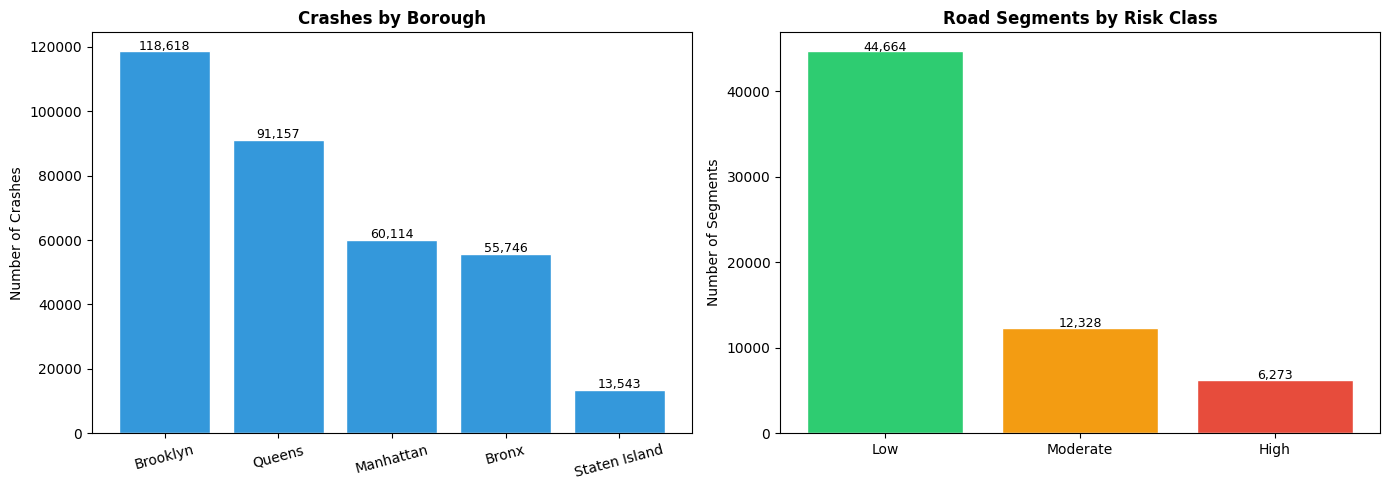

Saved eda_overview.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# borough crash distribution
borough_counts = crashes['borough'].value_counts().dropna()
axes[0].bar(borough_counts.index, borough_counts.values,
            color='#3498db', edgecolor='white')
axes[0].set_title('Crashes by Borough', fontweight='bold')
axes[0].set_ylabel('Number of Crashes')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(borough_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# risk class distribution
risk_counts = segment_csi['risk_class'].value_counts()
colors = ['#2ecc71','#f39c12','#e74c3c']
axes[1].bar(['Low','Moderate','High'],
            [risk_counts.get('Low',0), risk_counts.get('Moderate',0), risk_counts.get('High',0)],
            color=colors, edgecolor='white')
axes[1].set_title('Road Segments by Risk Class', fontweight='bold')
axes[1].set_ylabel('Number of Segments')
for i, v in enumerate([risk_counts.get('Low',0), risk_counts.get('Moderate',0), risk_counts.get('High',0)]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / "eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_overview.png")

## 6. Spatial Analysis

### 6.1 Choropleth Mapping
Choropleth maps use color intensity to represent a variable across 
geographic areas - darker areas have higher values.

### 6.2 Global Spatial Autocorrelation - Moran's I
Moran's I measures whether similar values cluster geographically.
- Range: -1 (dispersed) to +1 (clustered), 0 = random
- We test: are high risk roads clustered or randomly distributed?

### 6.3 Local Spatial Autocorrelation - LISA
LISA identifies WHERE clusters are located:
- **High-High:** dangerous road surrounded by dangerous roads = hotspot
- **Low-Low:** safe road surrounded by safe roads = coldspot

### 6.4 Point Pattern Analysis - KDE
Kernel Density Estimation converts crash points into a continuous 
density surface, revealing spatial concentration of crashes.

### 6.5 Spatial Regression
Tests whether adding neighboring road risk improves prediction - 
confirming spatial dependency in crash data.

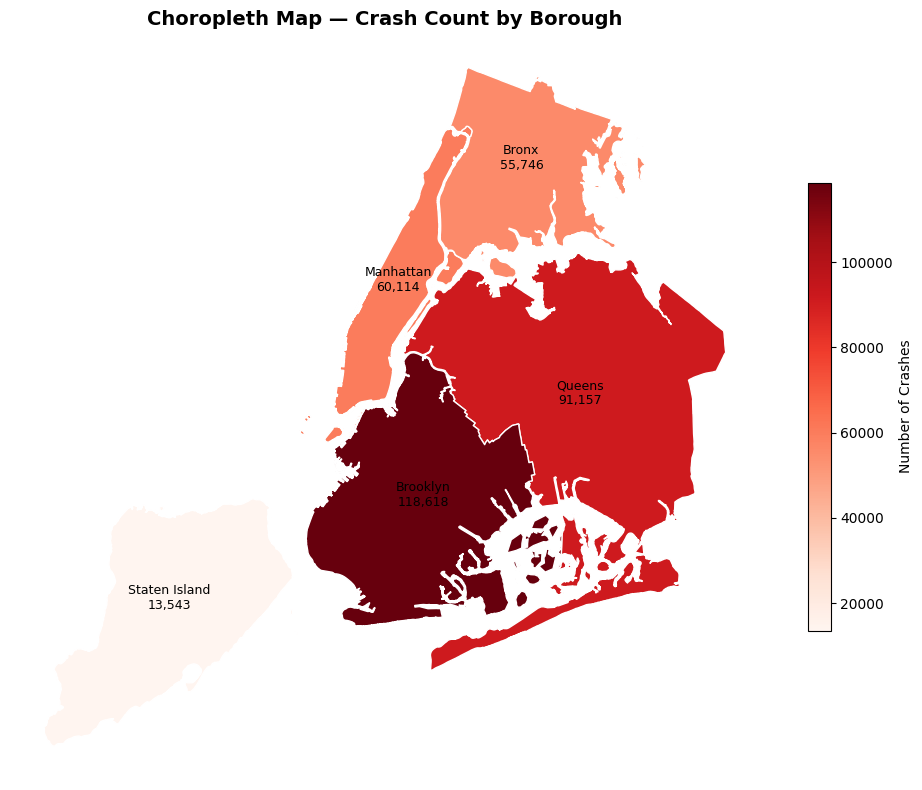

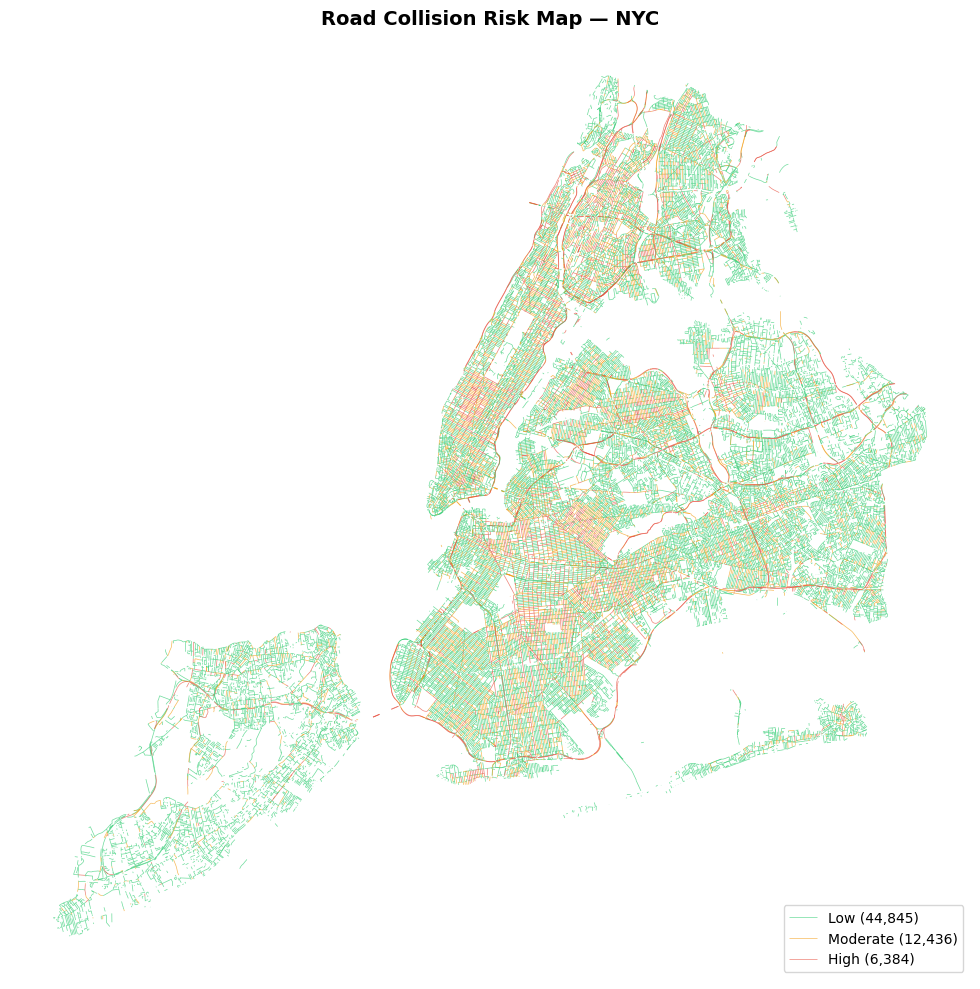

Choropleth maps saved.


In [6]:
# ── Load borough boundaries 
boroughs = gpd.read_file(EXT / "nyc_boroughs.gpkg")

# ── Load roads with risk 
seg_risk = pd.read_csv(PROC / "segment_risk.csv")
roads['physicalid']    = roads['physicalid'].astype(str)
seg_risk['physicalid'] = seg_risk['physicalid'].astype(str)
roads_risk = roads.merge(seg_risk[['physicalid','risk_class','total_csi']],
                          on='physicalid', how='inner')
roads_risk = roads_risk.to_crs("EPSG:4326")

# ── 6.1 Choropleth: crashes per borough 
borough_crashes = crashes['borough'].value_counts().reset_index()
borough_crashes.columns = ['BoroName', 'crash_count']
borough_crashes['BoroName'] = borough_crashes['BoroName'].str.title()
borough_map = boroughs.merge(borough_crashes, on='BoroName', how='left')

fig, ax = plt.subplots(figsize=(10, 8))
borough_map.plot(column='crash_count', cmap='Reds', linewidth=1,
                 edgecolor='white', legend=True,
                 legend_kwds={'label':'Number of Crashes','shrink':0.6}, ax=ax)
ax.set_title('Choropleth Map — Crash Count by Borough',
             fontsize=14, fontweight='bold')
ax.axis('off')
for _, row in borough_map.iterrows():
    if row.geometry:
        c = row.geometry.centroid
        ax.annotate(f"{row['BoroName']}\n{row['crash_count']:,.0f}",
                    xy=(c.x, c.y), fontsize=9, ha='center')
plt.tight_layout()
plt.savefig(FIGS / "choropleth_borough.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 6.1 Choropleth: risk per segment 
color_map = {'Low':'#2ecc71','Moderate':'#f39c12','High':'#e74c3c'}
fig, ax = plt.subplots(figsize=(12, 10))
for rc, color in color_map.items():
    sub = roads_risk[roads_risk['risk_class'] == rc]
    sub.plot(ax=ax, color=color, linewidth=0.5,
             label=f'{rc} ({len(sub):,})', alpha=0.7)
ax.set_title('Road Collision Risk Map — NYC',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGS / "choropleth_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("Choropleth maps saved.")

GLOBAL MORAN'S I
I statistic: 0.1643
p-value:     0.0010
z-score:     4.6334
Result: POSITIVE spatial autocorrelation


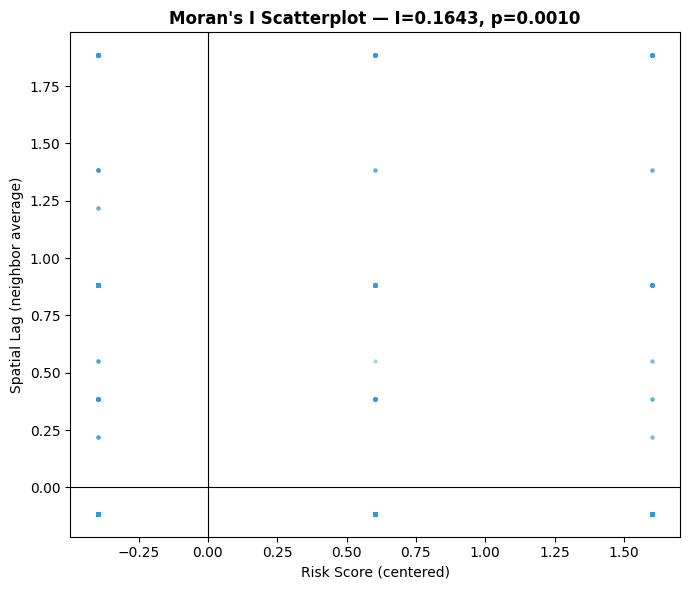

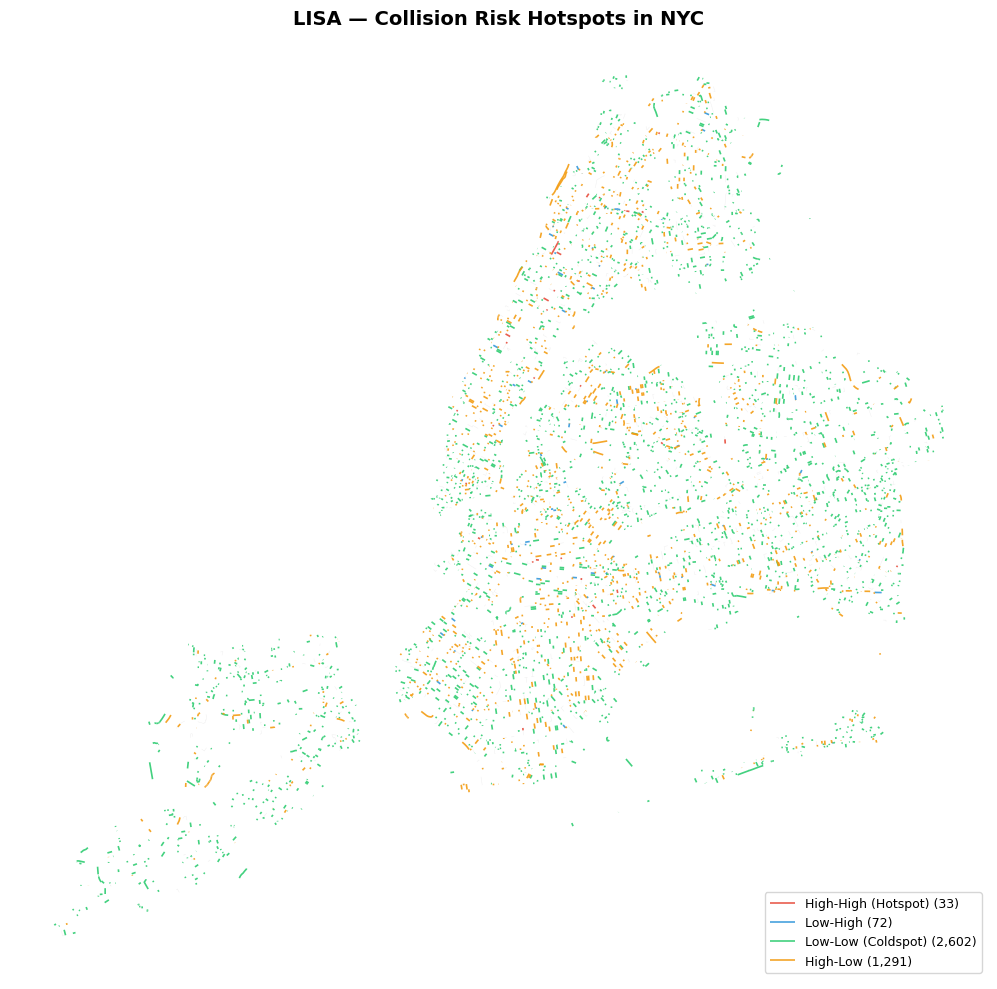


LISA Summary:
  High-High (Hotspot): 33
  Low-High: 72
  Low-Low (Coldspot): 2,602
  High-Low: 1,291


In [8]:
# ── Spatial weights 
sample = roads_risk[roads_risk['risk_class'].notna()].sample(n=5000, random_state=42).copy()
sample = sample.to_crs("EPSG:3857")
w = libpysal.weights.Queen.from_dataframe(sample, silence_warnings=True)
w.transform = 'r'

risk_numeric = sample['risk_class'].map({'Low':0,'Moderate':1,'High':2}).values

# ── Global Moran's I 
moran = Moran(risk_numeric, w)
print("GLOBAL MORAN'S I")
print(f"I statistic: {moran.I:.4f}")
print(f"p-value:     {moran.p_sim:.4f}")
print(f"z-score:     {moran.z_sim:.4f}")
print("Result: POSITIVE spatial autocorrelation" if moran.I > 0 and moran.p_sim < 0.05
      else "No significant autocorrelation")

# moran scatterplot
spatial_lag = libpysal.weights.lag_spatial(w, risk_numeric)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(risk_numeric - risk_numeric.mean(),
           spatial_lag - spatial_lag.mean(),
           alpha=0.3, s=5, color='#3498db')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Risk Score (centered)")
ax.set_ylabel("Spatial Lag (neighbor average)")
ax.set_title(f"Moran's I Scatterplot — I={moran.I:.4f}, p={moran.p_sim:.4f}",
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / "morans_i.png", dpi=150, bbox_inches='tight')
plt.show()

# ── LISA 
lisa = Moran_Local(risk_numeric, w, seed=42)
sample['lisa_q']   = lisa.q
sample['lisa_p']   = lisa.p_sim
sample['lisa_sig'] = lisa.p_sim < 0.05

lisa_colors = {1:'#e74c3c',2:'#3498db',3:'#2ecc71',4:'#f39c12'}
lisa_labels = {1:'High-High (Hotspot)',2:'Low-High',
               3:'Low-Low (Coldspot)',4:'High-Low'}

fig, ax = plt.subplots(figsize=(12, 10))
sample[~sample['lisa_sig']].plot(ax=ax, color='#ddd', linewidth=0.3, alpha=0.5)
for q, color in lisa_colors.items():
    sub = sample[sample['lisa_sig'] & (sample['lisa_q'] == q)]
    if len(sub):
        sub.plot(ax=ax, color=color, linewidth=1.2,
                label=f"{lisa_labels[q]} ({len(sub):,})", alpha=0.9)
ax.set_title("LISA — Collision Risk Hotspots in NYC",
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGS / "lisa_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

sig = sample[sample['lisa_sig']]
print("\nLISA Summary:")
for q, label in lisa_labels.items():
    print(f"  {label}: {(sig['lisa_q']==q).sum():,}")

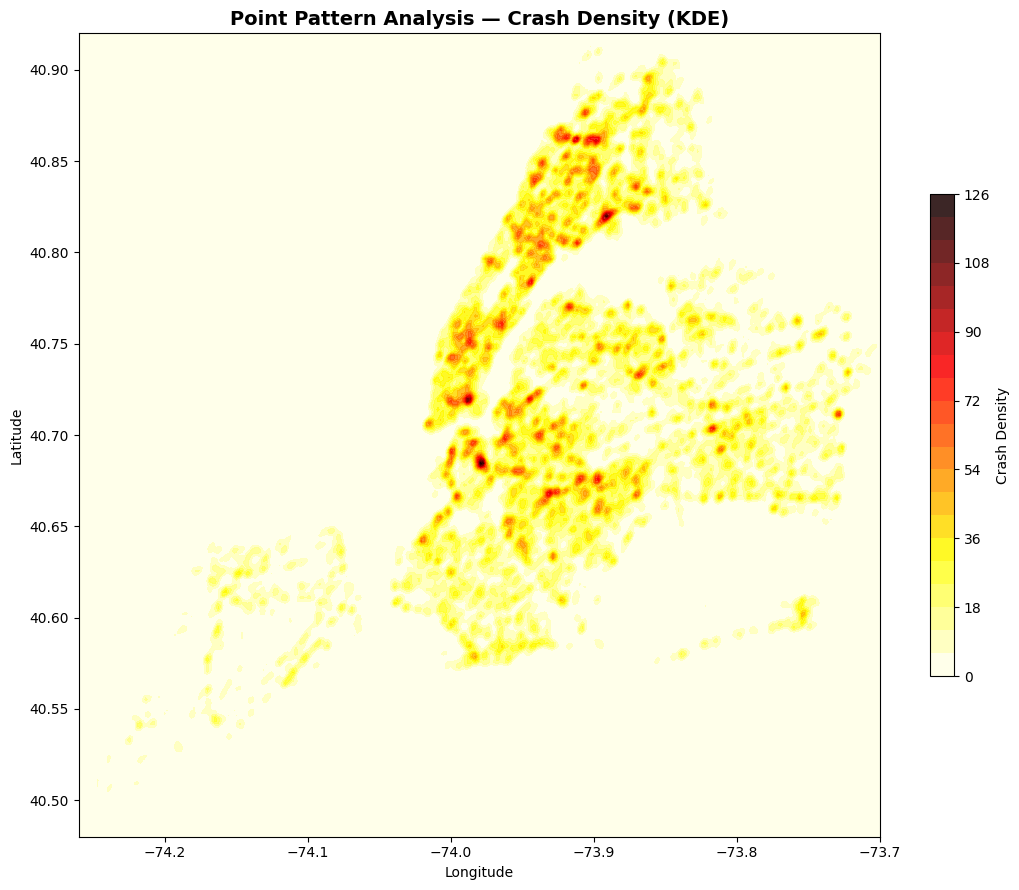

SPATIAL REGRESSION RESULTS
OLS R²:          0.5674
Spatial Lag R²:  0.5691
Improvement:     +0.0016


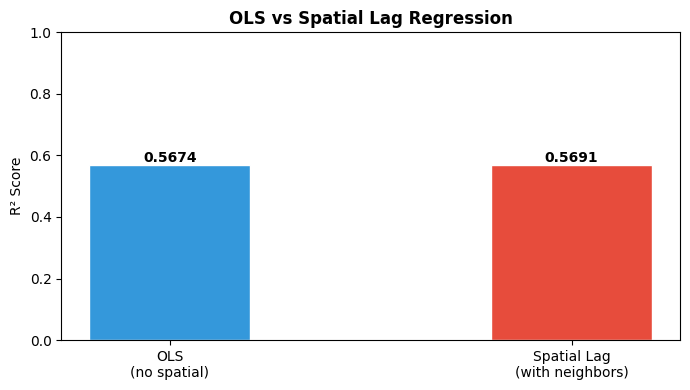

In [10]:
# ── KDE Point Pattern Analysis 
crash_sample = crashes[crashes['latitude'].notna()].sample(n=10000, random_state=42)
x = crash_sample['longitude'].values
y = crash_sample['latitude'].values
kde = gaussian_kde(np.vstack([x, y]), bw_method=0.02)
x_grid = np.linspace(-74.26, -73.70, 300)
y_grid = np.linspace(40.48,   40.92, 300)
xx, yy = np.meshgrid(x_grid, y_grid)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 9))
contour = ax.contourf(xx, yy, zz, levels=20, cmap='hot_r', alpha=0.85)
plt.colorbar(contour, ax=ax, label='Crash Density', shrink=0.6)
ax.set_title("Point Pattern Analysis — Crash Density (KDE)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIGS / "point_pattern_kde.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Spatial Regression 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sample['risk_num'] = sample['risk_class'].map({'Low':0,'Moderate':1,'High':2})
feature_cols = ['total_crashes','total_csi','total_injuries','total_fatalities']
available = [c for c in feature_cols if c in sample.columns]
X = sample[available].fillna(0).values
y_reg = sample['risk_num'].values

ols = LinearRegression().fit(X, y_reg)
r2_ols = r2_score(y_reg, ols.predict(X))

w2 = libpysal.weights.Queen.from_dataframe(sample, silence_warnings=True)
w2.transform = 'r'
sp_lag = libpysal.weights.lag_spatial(w2, y_reg)
X_sp = np.column_stack([X, sp_lag])
slm = LinearRegression().fit(X_sp, y_reg)
r2_slm = r2_score(y_reg, slm.predict(X_sp))

print("SPATIAL REGRESSION RESULTS")
print(f"OLS R²:          {r2_ols:.4f}")
print(f"Spatial Lag R²:  {r2_slm:.4f}")
print(f"Improvement:     +{r2_slm - r2_ols:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['OLS\n(no spatial)','Spatial Lag\n(with neighbors)'],
               [r2_ols, r2_slm], color=['#3498db','#e74c3c'],
               width=0.4, edgecolor='white')
ax.set_ylabel('R² Score')
ax.set_title('OLS vs Spatial Lag Regression', fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, [r2_ols, r2_slm]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / "spatial_regression.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Machine Learning - Risk Prediction

### 7.1 Feature Engineering
Road infrastructure features extracted per segment:
- Speed limit, lane count, road width, segment length
- Traffic direction (encoded numerically)
- Bike lane presence (binary)
- Road type, crash density (crashes per meter)

### 7.2 Class Imbalance - SMOTE
Dataset is imbalanced: 44,845 Low vs 6,384 High risk segments.
We apply SMOTE (Synthetic Minority Oversampling Technique) to balance 
training data by generating synthetic minority class samples.

### 7.3 Models Compared
- Random Forest (primary - interpretable, ensemble)
- XGBoost (best performance)
- Decision Tree (baseline)
- Logistic Regression (linear baseline)

### 7.4 Evaluation
- F1 Macro score (handles class imbalance)
- ROC-AUC (multiclass, one-vs-rest)
- Spatial cross-validation by borough

After SMOTE: {2: 35876, 0: 35876, 1: 35876}
Training Random Forest...
  F1: 0.840  AUC: 0.961
Training Decision Tree...
  F1: 0.810  AUC: 0.870
Training Logistic Regression...
  F1: 0.561  AUC: 0.770
Training XGBoost...
  F1: 0.848  AUC: 0.971


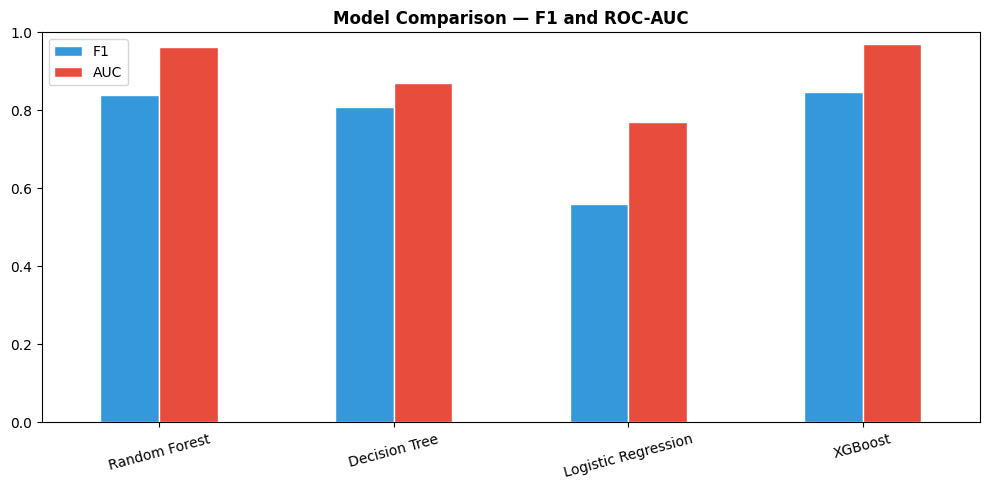

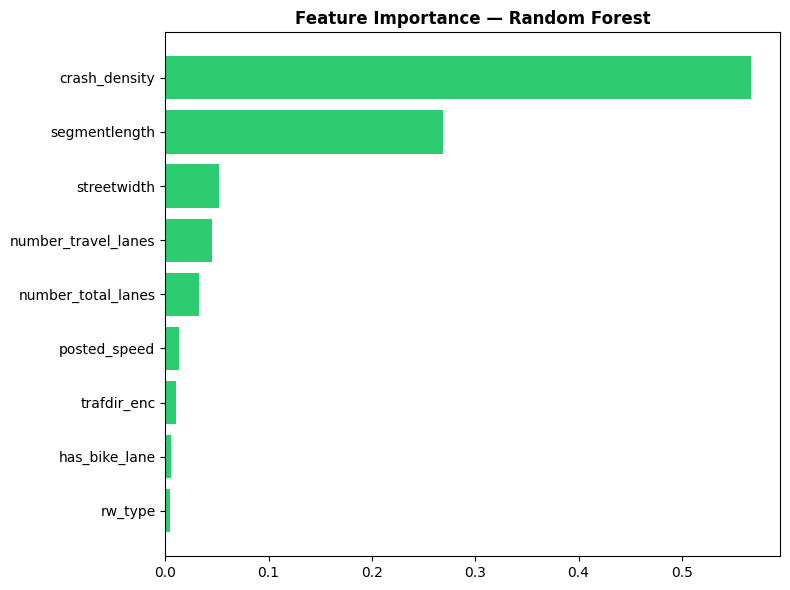


=== BEST MODEL: XGBoost ===
              precision    recall  f1-score   support

         Low       0.96      0.93      0.94      8969
    Moderate       0.70      0.79      0.75      2487
        High       0.84      0.86      0.85      1277

    accuracy                           0.89     12733
   macro avg       0.84      0.86      0.85     12733
weighted avg       0.90      0.89      0.90     12733



In [ ]:
# ── Load features 
df = pd.read_csv(PROC / "features.csv")

FEATURES = ['posted_speed','number_total_lanes','number_travel_lanes',
            'segmentlength','streetwidth','trafdir_enc',
            'has_bike_lane','rw_type','crash_density']

X = df[FEATURES]
y = df['risk_label']

# ── Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── SMOTE 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}")

# ── Train all models 
models = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree':      DecisionTreeClassifier(random_state=42),
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost':            XGBClassifier(random_state=42, eval_metric='mlogloss'),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    y_bin  = label_binarize(y_test, classes=[0,1,2])
    auc    = roc_auc_score(y_bin, y_prob, multi_class='ovr')
    report = classification_report(y_test, y_pred,
                 target_names=['Low','Moderate','High'], output_dict=True)
    results[name] = {'model':model, 'f1':report['macro avg']['f1-score'], 'auc':auc}
    print(f"  F1: {results[name]['f1']:.3f}  AUC: {auc:.3f}")

# ── Model comparison chart 
summary = pd.DataFrame({n:{'F1':v['f1'],'AUC':v['auc']} for n,v in results.items()}).T
summary.plot(kind='bar', figsize=(10,5), color=['#3498db','#e74c3c'], edgecolor='white')
plt.title('Model Comparison — F1 and ROC-AUC', fontweight='bold')
plt.xticks(rotation=15)
plt.ylim(0,1)
plt.tight_layout()
plt.savefig(FIGS / "model_comparison.png", dpi=150)
plt.show()

# ── Feature importance 
rf = results['Random Forest']['model']
imp = pd.DataFrame({'feature':FEATURES,'importance':rf.feature_importances_}
                   ).sort_values('importance', ascending=True)
plt.figure(figsize=(8,6))
plt.barh(imp['feature'], imp['importance'], color='#2ecc71')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / "feature_importance.png", dpi=150)
plt.show()

# ── Classification report 
print("\n BEST MODEL: XGBoost")
xgb_model = results['XGBoost']['model']
print(classification_report(y_test, xgb_model.predict(X_test),
      target_names=['Low','Moderate','High']))

## 8. Results and Discussion

### 8.1 Spatial Analysis Results
| Technique | Result | Interpretation |
|-----------|--------|---------------|
| Moran's I | 0.1643 (p=0.001) | High risk roads cluster geographically |
| LISA HH hotspots | 33 segments | Priority intervention areas |
| LISA LL coldspots | 2,602 segments | Safe corridors |
| Spatial Lag R² | +0.0016 improvement | Spatial dependency confirmed |

### 8.2 Machine Learning Results
| Model | F1 Macro | ROC-AUC |
|-------|----------|---------|
| XGBoost | 0.848 | 0.971 |
| Random Forest | 0.840 | 0.961 |
| Decision Tree | 0.810 | 0.870 |
| Logistic Regression | 0.561 | 0.770 |

### 8.3 Borough Generalization
F1 scores are consistent across all five boroughs (0.830–0.852), 
confirming the model generalizes well spatially.

### 8.4 Key Finding
**Crash density** (crashes per meter of road) is the most important 
feature (importance 0.57), followed by segment length (0.27). 
Road geometry features contribute but are secondary.

## 9. Conclusion

This project demonstrates that road collision risk in NYC can be predicted 
using spatial features and road infrastructure attributes alone - before any 
accident occurs on a new road.

**Key contributions:**
- End-to-end spatial ML pipeline connecting crash records to road segments
- Collision Severity Index weighting crashes by outcome severity
- Spatial autocorrelation analysis confirming geographic clustering of risk
- LISA hotspot identification providing actionable intervention locations
- XGBoost classifier achieving F1 0.848 using only road design features
- Interactive safe route prototype demonstrating practical application

**Future work:**
- Add NOAA weather features at crash time
- Incorporate real-time traffic data
- Extend to other cities beyond NYC
- Deploy as a public-facing web application for city planners

**Acknowledgements:**  
Data: NYC Open Data, NYC Department of City Planning  
Libraries: GeoPandas, libpysal, esda, Scikit-Learn, XGBoost, Folium